Unique stations: 32


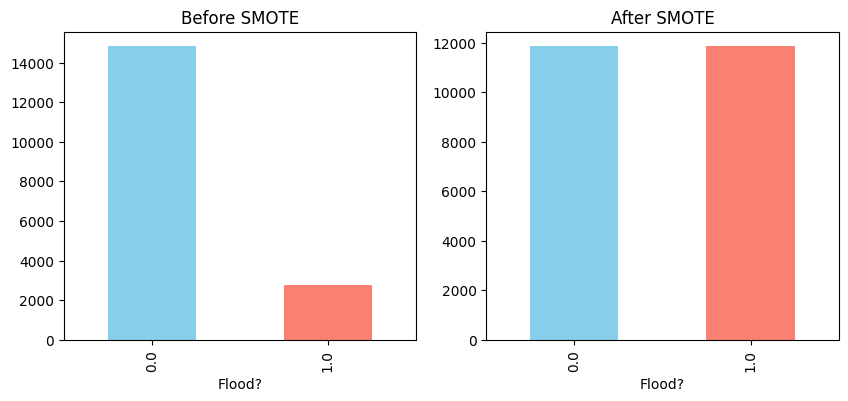

c:\Users\Abdul Gofran Emon\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:06:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Classification Report (Threshold 0.5):
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      2963
         1.0       0.92      0.95      0.93       549

    accuracy                           0.98      3512
   macro avg       0.96      0.97      0.96      3512
weighted avg       0.98      0.98      0.98      3512



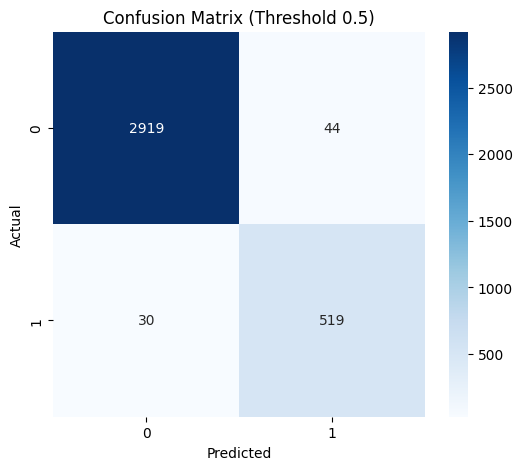

ROC-AUC Score: 0.99536173830614
RMSE: 0.1234774096235948
Threshold tuning results:
     Threshold  Precision    Recall  F1-score
0        0.10   0.802671  0.985428  0.884710
1        0.15   0.831530  0.979964  0.899666
2        0.20   0.842767  0.976321  0.904641
3        0.25   0.866883  0.972678  0.916738
4        0.30   0.889447  0.967213  0.926702
5        0.35   0.894915  0.961749  0.927129
6        0.40   0.905336  0.958106  0.930973
7        0.45   0.915937  0.952641  0.933929
8        0.50   0.921847  0.945355  0.933453
9        0.55   0.928058  0.939891  0.933937
10       0.60   0.943015  0.934426  0.938701
11       0.65   0.946097  0.927140  0.936523
12       0.70   0.954631  0.919854  0.936920
13       0.75   0.965451  0.916211  0.940187
14       0.80   0.970356  0.894353  0.930806
15       0.85   0.979424  0.867031  0.919807

✅ Classification Report at Threshold 0.5:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      2963

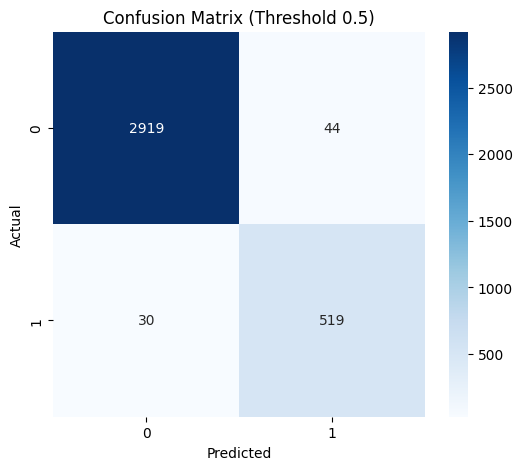

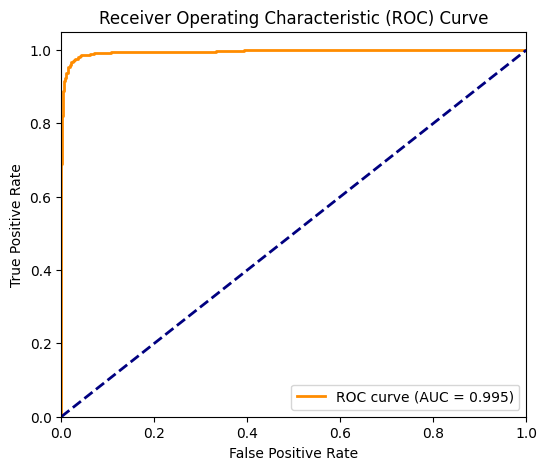

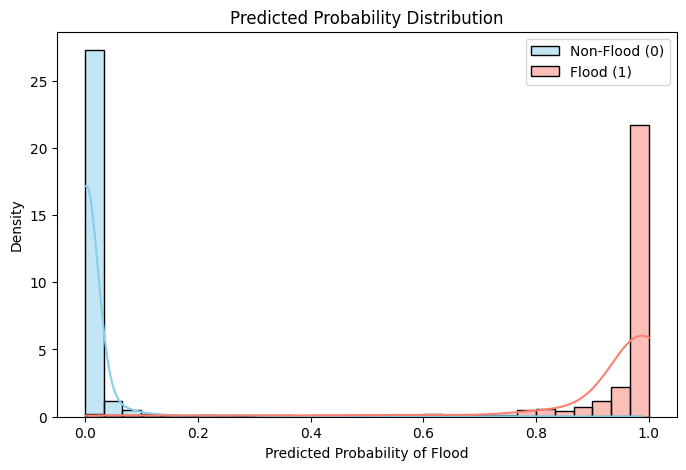

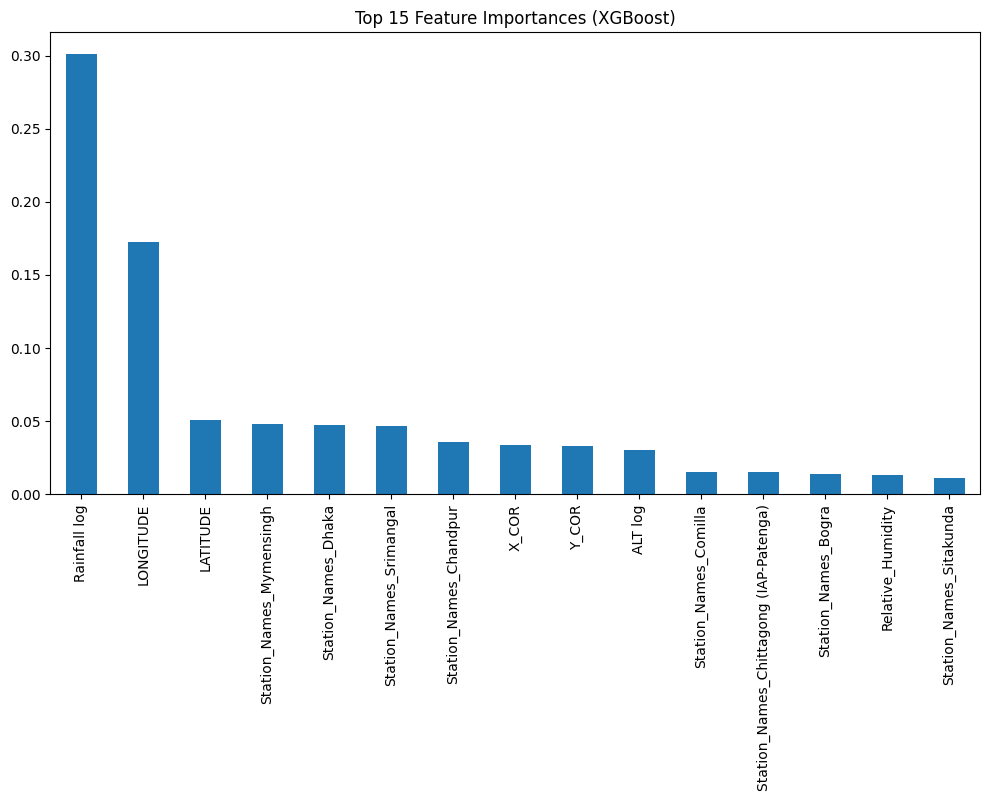

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, mean_squared_error, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# Load Preprocessed CSV

df = pd.read_csv('flood_data_preprocessed.csv')
print("Unique stations:", df['Station_Names'].nunique())

numeric_features = ['Max_Temp','Min_Temp','Rainfall log','Relative_Humidity','Wind_Speed log',
                    'Cloud_Coverage','Bright_Sunshine','X_COR','Y_COR','LATITUDE','LONGITUDE','ALT log','Period']

# One-hot encode categorical column
df_dummies = pd.get_dummies(df[['Station_Names']], drop_first=True)

# Combine numeric and categorical features
X = pd.concat([df[numeric_features], df_dummies], axis=1)
y = df['Flood?']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling Numeric Features
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

# Handle Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Visualize impact of SMOTE
fig, ax = plt.subplots(1, 2, figsize=(10,4))
y.value_counts().plot(kind='bar', ax=ax[0], title='Before SMOTE', color=['skyblue','salmon'])
y_train_res.value_counts().plot(kind='bar', ax=ax[1], title='After SMOTE', color=['skyblue','salmon'])
plt.show()

# Train XGBoost Classifier
# Optional: calculate scale_pos_weight if you don't use SMOTE
# pos = y_train_res.sum()
# neg = len(y_train_res) - pos
# scale_pos_weight = neg / pos

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
    # scale_pos_weight=scale_pos_weight  # if not using SMOTE
)

xgb_model.fit(X_train_res, y_train_res)


# Predictions and Probabilities
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:,1]


# Evaluate Default Threshold (0.5)
print("✅ Classification Report (Threshold 0.5):")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Threshold 0.5)')
plt.show()

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC Score:", roc_auc)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_proba))
print("RMSE:", rmse)

# Threshold Tuning
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_thresh, average='binary')
    results.append([t, precision, recall, f1])

results_df = pd.DataFrame(results, columns=['Threshold','Precision','Recall','F1-score'])
print("Threshold tuning results:\n", results_df)

# Choose best threshold (high recall for floods)
best_threshold = 0.50
y_pred_best = (y_proba >= best_threshold).astype(int)

print(f"\n✅ Classification Report at Threshold {best_threshold}:")
print(classification_report(y_test, y_pred_best))

# Confusion matrix for best threshold
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (Threshold {best_threshold})')
plt.show()

# ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Predicted Probability Distribution
plt.figure(figsize=(8,5))
sns.histplot(y_proba[y_test==0], color='skyblue', label='Non-Flood (0)', bins=30, stat='density', kde=True)
sns.histplot(y_proba[y_test==1], color='salmon', label='Flood (1)', bins=30, stat='density', kde=True)
plt.xlabel('Predicted Probability of Flood')
plt.ylabel('Density')
plt.title('Predicted Probability Distribution')
plt.legend()
plt.show()

# Feature Importance
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(12,6))
importances[:15].plot(kind='bar')
plt.title("Top 15 Feature Importances (XGBoost)")
plt.show()
